<a href="https://colab.research.google.com/github/moaazahmed0/Titanic-Survival-Classification/blob/main/Titanic_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

In [41]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Titanic Classification/Titanic-Dataset.csv")

In [42]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
df.shape

(891, 12)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [45]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [47]:
df.duplicated().sum()

np.int64(111)

In [48]:
df.drop_duplicates(inplace=True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  780 non-null    int64  
 1   Pclass    780 non-null    int64  
 2   Sex       780 non-null    object 
 3   Age       676 non-null    float64
 4   SibSp     780 non-null    int64  
 5   Parch     780 non-null    int64  
 6   Fare      780 non-null    float64
 7   Embarked  778 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 54.8+ KB


In [50]:
df = df.dropna(subset=["Embarked"])

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 778 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  778 non-null    int64  
 1   Pclass    778 non-null    int64  
 2   Sex       778 non-null    object 
 3   Age       674 non-null    float64
 4   SibSp     778 non-null    int64  
 5   Parch     778 non-null    int64  
 6   Fare      778 non-null    float64
 7   Embarked  778 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 54.7+ KB


In [52]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 778 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  778 non-null    int64  
 1   Pclass    778 non-null    int64  
 2   Sex       778 non-null    object 
 3   Age       778 non-null    float64
 4   SibSp     778 non-null    int64  
 5   Parch     778 non-null    int64  
 6   Fare      778 non-null    float64
 7   Embarked  778 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 54.7+ KB


In [55]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000
mean,0.411311,2.249357,29.752849,0.526992,0.419023,34.712987
std,0.492388,0.853206,13.674537,0.988956,0.839346,52.280326
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.250000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,29.752849,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,33.890600
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [53]:
df.describe(include=['object'])

,Sex,Embarked
count,778,778
unique,2,3
top,male,S
freq,488,565


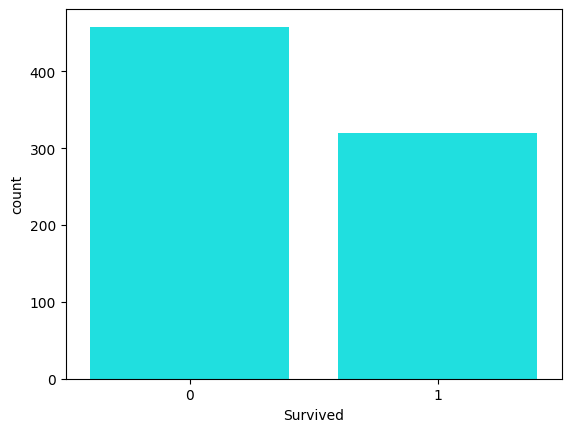

In [56]:
sns.countplot(data=df,x="Survived",color="cyan")
plt.show()

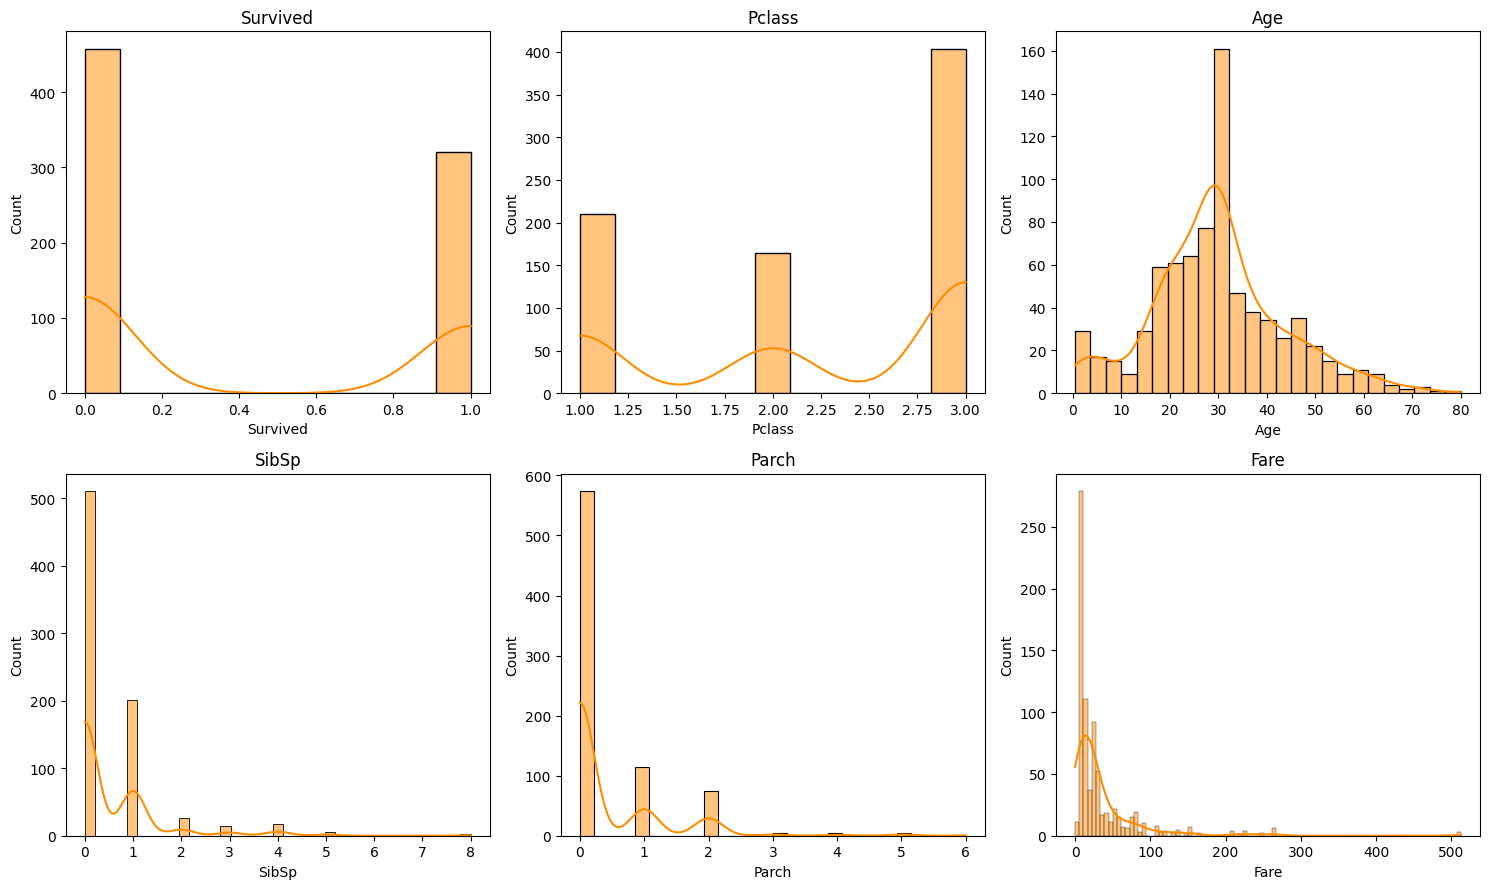

In [57]:
plt.figure(figsize=(15,9))
num_cols=df.select_dtypes(include="number").columns
for i,col in enumerate(num_cols):
  plt.subplot(2,3,i+1)
  sns.histplot(data=df,x=col,color="darkorange",kde=True)
  plt.title(col)
plt.tight_layout()
plt.show()

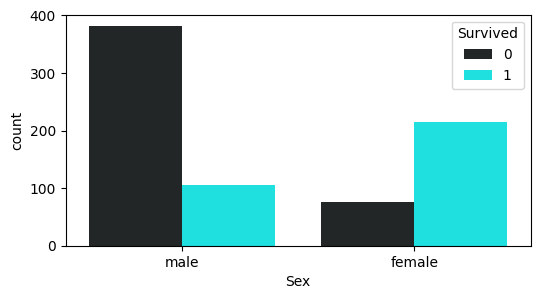

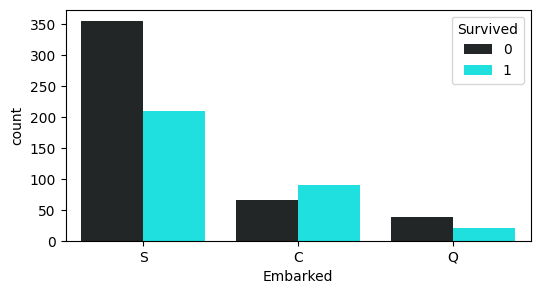

In [58]:
for col in df.select_dtypes(include="object").columns:
  plt.figure(figsize=(6,3))
  sns.countplot(data=df,x=col,hue="Survived",color="cyan")
  plt.show()

In [59]:
continus_cols=df[["Age","Fare"]]
continus_cols.skew()

,0
Age,0.394149
Fare,4.573367


In [60]:
df['Fare'] = np.log1p(df['Fare'])

In [61]:
df["Fare"].skew()

np.float64(0.4562190888448181)

In [62]:
df["Fare"].describe()

,Fare
count,778.000000
mean,3.043764
std,0.959833
min,0.000000
25%,2.202765
50%,2.827314
75%,3.552196
max,6.240917


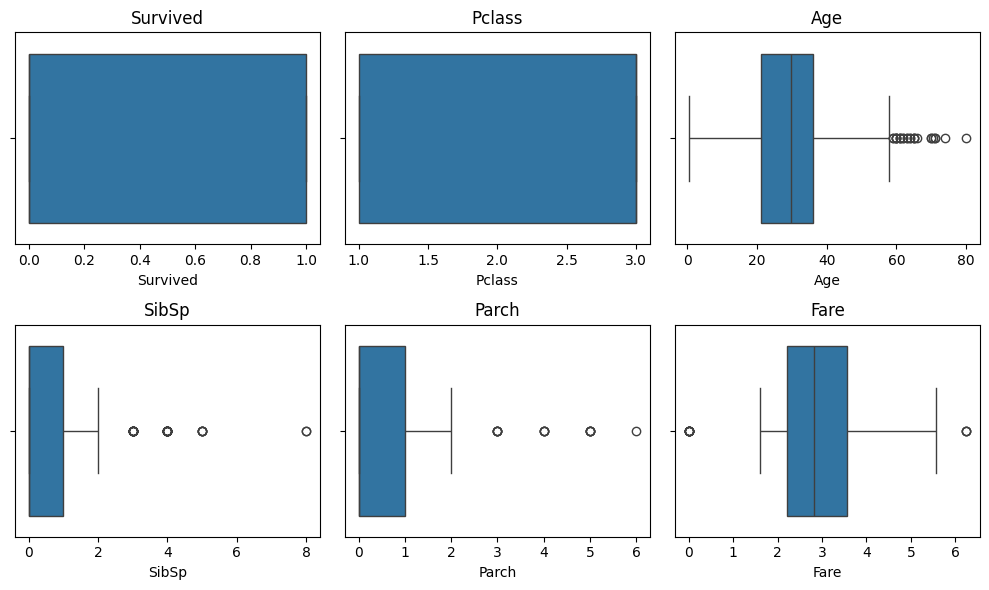

In [63]:

plt.figure(figsize=(10,6))
for i,col in enumerate(num_cols):
  plt.subplot(2,3,i+1)
  sns.boxplot(data=df,x=col)
  plt.title(col)
plt.tight_layout()
plt.show()

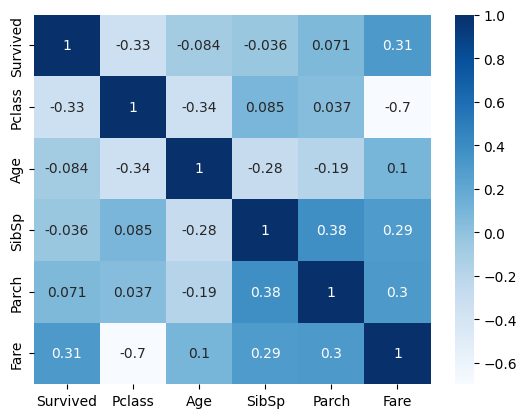

In [64]:
sns.heatmap(df.select_dtypes(include="number").corr(),annot=True,cmap="Blues")
plt.show()

In [65]:
x=df.drop(columns=["Survived"])
y=df["Survived"]
cat_Cols = x.select_dtypes(include='object').columns
num_Cols = x.select_dtypes(include='number').columns

In [66]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,shuffle=True,random_state=42)

In [67]:
my_transformer=ColumnTransformer([
    ("numbers",StandardScaler(),num_Cols),
    ("cat",OneHotEncoder(),cat_Cols)

])

In [68]:
x_train=my_transformer.fit_transform(x_train)
x_test=my_transformer.transform(x_test)

In [69]:
x_train

array([[ 0.86565595, -0.76537852, -0.51625305, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.86565595, -1.85652036,  0.45680573, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.86565595,  0.47124889, -0.51625305, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.31772427,  0.01681368, -0.51625305, ...,  0.        ,
         0.        ,  1.        ],
       [-1.50110449,  1.19867678, -0.51625305, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.86565595,  0.01681368, -0.51625305, ...,  0.        ,
         0.        ,  1.        ]])

In [70]:
x_test

array([[ 0.86565595, -0.11069342, -0.51625305, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.86565595,  0.18027774, -0.51625305, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.86565595, -0.47440736, -0.51625305, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.31772427, -0.47440736, -0.51625305, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.86565595, -0.03795063, -0.51625305, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.86565595,  0.83496284, -0.51625305, ...,  0.        ,
         0.        ,  1.        ]])

In [71]:
def train_eval(model,X_train,X_test,y_train,y_test):
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  y_pred_train=model.predict(X_train)
  print("Evaluate on test data")
  print()
  print("Classification report: ",classification_report(y_test,y_pred))
  print("-"*20)
  print("Confusion matrix: \n")
  print(confusion_matrix(y_test,y_pred))
  print("-"*20)
  print("Accuracy score: ",accuracy_score(y_test,y_pred))
  print("-"*60)
  print("Evaluate on train data")
  print()
  print("Classification report: ",classification_report(y_train,y_pred_train))
  print("-"*20)
  print("Confusion matrix: \n",confusion_matrix(y_train,y_pred_train))
  print("-"*20)
  print("Accuracy score: ",accuracy_score(y_train,y_pred_train))


In [72]:
LogisticRegression_model=LogisticRegression()
train_eval(LogisticRegression_model,x_train,x_test,y_train,y_test)

Evaluate on test data

Classification report:                precision    recall  f1-score   support

           0       0.82      0.82      0.82        92
           1       0.73      0.73      0.73        64

    accuracy                           0.78       156
   macro avg       0.77      0.77      0.77       156
weighted avg       0.78      0.78      0.78       156

--------------------
Confusion matrix: 

[[75 17]
 [17 47]]
--------------------
Accuracy score:  0.782051282051282
------------------------------------------------------------
Evaluate on train data

Classification report:                precision    recall  f1-score   support

           0       0.80      0.81      0.81       366
           1       0.73      0.71      0.72       256

    accuracy                           0.77       622
   macro avg       0.77      0.76      0.77       622
weighted avg       0.77      0.77      0.77       622

--------------------
Confusion matrix: 
 [[298  68]
 [ 73 183]]
----------

In [73]:
svm_model_linear = SVC(kernel='linear', C=1)
train_eval(svm_model_linear, x_train, x_test, y_train, y_test)

Evaluate on test data

Classification report:                precision    recall  f1-score   support

           0       0.76      0.83      0.79        92
           1       0.71      0.62      0.67        64

    accuracy                           0.74       156
   macro avg       0.74      0.73      0.73       156
weighted avg       0.74      0.74      0.74       156

--------------------
Confusion matrix: 

[[76 16]
 [24 40]]
--------------------
Accuracy score:  0.7435897435897436
------------------------------------------------------------
Evaluate on train data

Classification report:                precision    recall  f1-score   support

           0       0.79      0.84      0.81       366
           1       0.74      0.68      0.71       256

    accuracy                           0.77       622
   macro avg       0.77      0.76      0.76       622
weighted avg       0.77      0.77      0.77       622

--------------------
Confusion matrix: 
 [[306  60]
 [ 82 174]]
---------

In [74]:
svm_model_rbf = SVC(kernel='rbf', C=10)
train_eval(svm_model_rbf, x_train, x_test, y_train, y_test)

Evaluate on test data

Classification report:                precision    recall  f1-score   support

           0       0.76      0.93      0.84        92
           1       0.86      0.58      0.69        64

    accuracy                           0.79       156
   macro avg       0.81      0.76      0.77       156
weighted avg       0.80      0.79      0.78       156

--------------------
Confusion matrix: 

[[86  6]
 [27 37]]
--------------------
Accuracy score:  0.7884615384615384
------------------------------------------------------------
Evaluate on train data

Classification report:                precision    recall  f1-score   support

           0       0.82      0.95      0.88       366
           1       0.91      0.70      0.79       256

    accuracy                           0.85       622
   macro avg       0.86      0.82      0.83       622
weighted avg       0.85      0.85      0.84       622

--------------------
Confusion matrix: 
 [[348  18]
 [ 78 178]]
---------

In [75]:
knn_model = KNeighborsClassifier(n_neighbors=5)
train_eval(knn_model, x_train, x_test, y_train, y_test)

Evaluate on test data

Classification report:                precision    recall  f1-score   support

           0       0.78      0.90      0.83        92
           1       0.82      0.62      0.71        64

    accuracy                           0.79       156
   macro avg       0.80      0.76      0.77       156
weighted avg       0.79      0.79      0.78       156

--------------------
Confusion matrix: 

[[83  9]
 [24 40]]
--------------------
Accuracy score:  0.7884615384615384
------------------------------------------------------------
Evaluate on train data

Classification report:                precision    recall  f1-score   support

           0       0.82      0.92      0.87       366
           1       0.86      0.72      0.78       256

    accuracy                           0.84       622
   macro avg       0.84      0.82      0.83       622
weighted avg       0.84      0.84      0.83       622

--------------------
Confusion matrix: 
 [[337  29]
 [ 72 184]]
---------

In [76]:
naive_bayes_model = GaussianNB()
train_eval(naive_bayes_model, x_train, x_test, y_train, y_test)

Evaluate on test data

Classification report:                precision    recall  f1-score   support

           0       0.82      0.78      0.80        92
           1       0.71      0.75      0.73        64

    accuracy                           0.77       156
   macro avg       0.76      0.77      0.76       156
weighted avg       0.77      0.77      0.77       156

--------------------
Confusion matrix: 

[[72 20]
 [16 48]]
--------------------
Accuracy score:  0.7692307692307693
------------------------------------------------------------
Evaluate on train data

Classification report:                precision    recall  f1-score   support

           0       0.80      0.79      0.80       366
           1       0.71      0.71      0.71       256

    accuracy                           0.76       622
   macro avg       0.75      0.75      0.75       622
weighted avg       0.76      0.76      0.76       622

--------------------
Confusion matrix: 
 [[290  76]
 [ 73 183]]
---------

In [77]:
decision_tree_model = DecisionTreeClassifier(random_state=41,criterion="gini",max_depth=5)
train_eval(decision_tree_model, x_train, x_test, y_train, y_test)

Evaluate on test data

Classification report:                precision    recall  f1-score   support

           0       0.77      0.93      0.85        92
           1       0.87      0.61      0.72        64

    accuracy                           0.80       156
   macro avg       0.82      0.77      0.78       156
weighted avg       0.81      0.80      0.79       156

--------------------
Confusion matrix: 

[[86  6]
 [25 39]]
--------------------
Accuracy score:  0.8012820512820513
------------------------------------------------------------
Evaluate on train data

Classification report:                precision    recall  f1-score   support

           0       0.80      0.96      0.87       366
           1       0.93      0.64      0.76       256

    accuracy                           0.83       622
   macro avg       0.86      0.80      0.82       622
weighted avg       0.85      0.83      0.83       622

--------------------
Confusion matrix: 
 [[353  13]
 [ 91 165]]
---------